# Phase 1 — Simulated GRB Detection Pipeline

This notebook demonstrates the Phase 1 implementation of **grbtrace**:
- synthetic GRB light curve generation
- threshold-based burst detection
- T90 feature extraction
- visualization

No real telescope data is used yet.

In [13]:
%%bash
# Recreate folders (safe to re-run)
mkdir -p grbtrace/src/grbtrace/io grbtrace/tests grbtrace/notebooks

# Install deps (Phase 1 deps only)
python -m pip -q install numpy scipy matplotlib pytest

In [1]:
%%bash
mkdir -p grbtrace/src/grbtrace/io grbtrace/notebooks grbtrace/tests
touch grbtrace/src/grbtrace/__init__.py
touch grbtrace/src/grbtrace/io/__init__.py

In [2]:
!pip -q install numpy scipy matplotlib

In [3]:
%%bash
cat > grbtrace/src/grbtrace/simulate.py <<'PY'
import numpy as np

def simulate_binned_lightcurve(
    duration: float = 40.0,
    dt: float = 0.064,
    background_rate: float = 200.0,   # counts/sec
    burst_peak_rate: float = 2000.0,  # counts/sec
    burst_t0: float = 20.0,
    burst_sigma: float = 0.8,
    seed: int = 7,
):
    """
    Returns (t, counts, dt) where:
    - t: time array (seconds), one per bin
    - counts: Poisson counts per bin
    - dt: bin width (seconds)
    """
    rng = np.random.default_rng(seed)
    t = np.arange(0, duration, dt)

    bkg = np.full_like(t, background_rate)
    burst = burst_peak_rate * np.exp(-0.5 * ((t - burst_t0) / burst_sigma) ** 2)

    rate = bkg + burst
    expected_counts = rate * dt
    counts = rng.poisson(expected_counts)

    return t, counts, dt
PY

In [4]:
%%bash
cat > grbtrace/src/grbtrace/detect.py <<'PY'
import numpy as np
from dataclasses import dataclass

@dataclass(frozen=True)
class DetectionResult:
    start_idx: int
    end_idx: int
    threshold: float
    bkg_median: float
    bkg_std_est: float

def detect_burst_threshold(counts: np.ndarray, sigma: float = 5.0):
    """
    Simple burst detection: detect contiguous region where counts exceed a robust threshold.

    Returns DetectionResult or None if no burst is detected.
    """
    counts = np.asarray(counts)

    med = float(np.median(counts))
    mad = float(np.median(np.abs(counts - med))) + 1e-12
    std = 1.4826 * mad  # MAD->std approx for normal dist
    threshold = med + sigma * std

    mask = counts > threshold
    if not np.any(mask):
        return None

    idx = np.where(mask)[0]
    start_idx, end_idx = int(idx[0]), int(idx[-1])

    return DetectionResult(
        start_idx=start_idx,
        end_idx=end_idx,
        threshold=float(threshold),
        bkg_median=med,
        bkg_std_est=float(std),
    )
PY

In [5]:
%%bash
cat > grbtrace/src/grbtrace/features.py <<'PY'
import numpy as np
from dataclasses import dataclass

@dataclass(frozen=True)
class T90Result:
    t90: float
    t5: float
    t95: float
    total_counts: float

def compute_t90(t: np.ndarray, counts: np.ndarray, start_idx: int, end_idx: int):
    """
    Compute T90 inside a detected window.
    T90 = time between 5% and 95% of cumulative counts in window.
    """
    t = np.asarray(t, dtype=float)
    counts = np.asarray(counts, dtype=float)

    window_t = t[start_idx:end_idx + 1]
    window_counts = counts[start_idx:end_idx + 1]

    cum = np.cumsum(window_counts)
    total = float(cum[-1])

    if total <= 0 or len(cum) < 2:
        return None

    t5 = float(np.interp(0.05 * total, cum, window_t))
    t95 = float(np.interp(0.95 * total, cum, window_t))
    t90 = float(t95 - t5)

    return T90Result(t90=t90, t5=t5, t95=t95, total_counts=total)

def peak_rate(counts: np.ndarray, dt: float) -> float:
    counts = np.asarray(counts, dtype=float)
    return float(np.max(counts) / dt)

def fluence_proxy(counts: np.ndarray) -> float:
    counts = np.asarray(counts, dtype=float)
    return float(np.sum(counts))
PY

In [6]:
%%bash
cat > grbtrace/src/grbtrace/plot.py <<'PY'
import numpy as np
import matplotlib.pyplot as plt

def plot_lightcurve(t, counts, threshold=None, window=None, title="Light curve"):
    t = np.asarray(t)
    counts = np.asarray(counts)

    plt.figure(figsize=(12, 4))
    plt.step(t, counts, where="mid", linewidth=1.0)
    plt.xlabel("time (s)")
    plt.ylabel("counts / bin")
    plt.title(title)

    if threshold is not None:
        plt.axhline(threshold, linestyle="--", linewidth=1.0, label=f"threshold={threshold:.1f}")

    if window is not None:
        t0, t1 = window
        plt.axvspan(t0, t1, alpha=0.2, label="detected window")

    if threshold is not None or window is not None:
        plt.legend()

    plt.tight_layout()
    plt.show()
PY

In [7]:
%%bash
cat > grbtrace/notebooks/run_simulated_demo.py <<'PY'
import sys
import os

# Make src importable in Colab
sys.path.insert(0, os.path.abspath("grbtrace/src"))

from grbtrace.simulate import simulate_binned_lightcurve
from grbtrace.detect import detect_burst_threshold
from grbtrace.features import compute_t90, peak_rate, fluence_proxy
from grbtrace.plot import plot_lightcurve

def main():
    t, counts, dt = simulate_binned_lightcurve()

    det = detect_burst_threshold(counts, sigma=5.0)

    if det is None:
        print("No burst detected.")
        plot_lightcurve(t, counts, title="Simulated light curve (no detection)")
        return

    window = (t[det.start_idx], t[det.end_idx])
    t90res = compute_t90(t, counts, det.start_idx, det.end_idx)

    plot_lightcurve(
        t, counts,
        threshold=det.threshold,
        window=window,
        title="Simulated GRB light curve + detection"
    )

    print("=== Detection ===")
    print(f"Window: {window[0]:.3f}s → {window[1]:.3f}s")
    print(f"Threshold: {det.threshold:.2f} (median={det.bkg_median:.2f}, std_est={det.bkg_std_est:.2f})")

    print("\n=== Features ===")
    if t90res is None:
        print("T90 could not be computed.")
    else:
        print(f"T90: {t90res.t90:.3f}s (t5={t90res.t5:.3f}s, t95={t90res.t95:.3f}s)")
        print(f"Total counts in window: {t90res.total_counts:.0f}")

    print(f"Peak rate (global): {peak_rate(counts, dt):.1f} counts/s")
    print(f"Fluence proxy (global): {fluence_proxy(counts):.0f} counts")

if __name__ == "__main__":
    main()
PY

In [12]:
!python grbtrace/notebooks/run_simulated_demo.py

Figure(1200x400)
=== Detection ===
Window: 18.496s → 21.632s
Threshold: 35.24 (median=13.00, std_est=4.45)

=== Features ===
T90: 2.520s (t5=18.741s, t95=21.261s)
Total counts in window: 4546
Peak rate (global): 2562.5 counts/s
Fluence proxy (global): 12096 counts


In [9]:
!pip -q install pytest

In [10]:
%%bash
cat > grbtrace/tests/test_features.py <<'PY'
import os, sys

# Make src importable in Colab
sys.path.insert(0, os.path.abspath("grbtrace/src"))

from grbtrace.simulate import simulate_binned_lightcurve
from grbtrace.detect import detect_burst_threshold
from grbtrace.features import compute_t90

def test_t90_reasonable_for_simulation():
    t, counts, dt = simulate_binned_lightcurve(seed=7)
    det = detect_burst_threshold(counts, sigma=5.0)

    assert det is not None, "Burst should be detected in the default simulation."

    t90res = compute_t90(t, counts, det.start_idx, det.end_idx)
    assert t90res is not None, "T90 should be computable."

    # Sanity range for THIS simulation setup (not physics-truth, just regression safety)
    assert 0.5 < t90res.t90 < 6.0, f"T90 looks unreasonable: {t90res.t90}"
PY

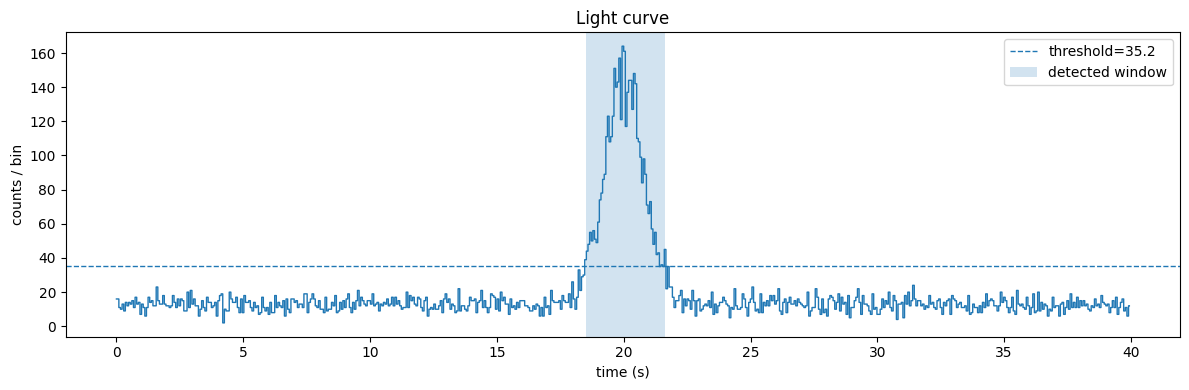

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("grbtrace/src"))

from grbtrace.simulate import simulate_binned_lightcurve
from grbtrace.detect import detect_burst_threshold
from grbtrace.features import compute_t90
from grbtrace.plot import plot_lightcurve

t, counts, dt = simulate_binned_lightcurve()

det = detect_burst_threshold(counts, sigma=5.0)

window = (t[det.start_idx], t[det.end_idx])
t90res = compute_t90(t, counts, det.start_idx, det.end_idx)

plot_lightcurve(t, counts, threshold=det.threshold, window=window)